In [34]:
import tkinter as tk
from tkinter import filedialog
import sys
import pandas as pd
import numpy as np

ruta = r"C:\Users\andy0\Documents\Tesis\00_Dataset\2_TENERIFE\6_SEGAI\segai_building_data.xlsx"

df = pd.read_excel(ruta)

df.head()


,Date and time,Temperature (ºC),Humidity (g/m3),Wind Speed (m/s),Irradiance (W/m2),PV(W),Load(W)
0,2023-04-04 00:00:00,14.37,85.87,7.33,0.0,0.0,33387.33333
1,2023-04-04 00:30:00,14.20,91.20,8.10,0.0,0.0,23725.33333
2,2023-04-04 01:00:00,14.07,92.03,7.90,0.0,0.0,24043.83333
3,2023-04-04 01:30:00,14.23,91.57,7.40,0.0,0.0,23196.50000
4,2023-04-04 02:00:00,14.30,86.63,7.13,0.0,0.0,22820.83333


In [35]:
print(df["Temperature (ºC)"].iloc[1])

14.2


In [36]:
def date_prepocessing(df):
    df['Date and time'] = pd.to_datetime(df['Date and time'], format='%d.%m.%Y %H:%M')
    df = df.set_index("Date and time")
    del df["Temperature (ºC)"]
    del df["Humidity (g/m3)"]
    del df["Wind Speed (m/s)"]
    del df["Irradiance (W/m2)"]
    del df["PV(W)"]
    df['Load(W)'] = pd.to_numeric(df['Load(W)'], errors='coerce')
    fecha_min = df.index.min()
    fecha_max = df.index.max()
    rango_horario_completo = pd.date_range(start=fecha_min, end=fecha_max, freq="15min")
    

    df = df.reindex(rango_horario_completo)
    

    df = df.interpolate(method="linear")
    
    # Renombrar el índice
    df.index.name = "DATETIME"
    df['PLANT CONSUMPTION (KWh)'] = (df['Load(W)'] / 1000)
    del df["Load(W)"]

    return df

df = date_prepocessing(df)
df.head()

,PLANT CONSUMPTION (KWh)
DATETIME,
2023-04-04 00:00:00,33.387333
2023-04-04 00:15:00,28.556333
2023-04-04 00:30:00,23.725333
2023-04-04 00:45:00,23.884583
2023-04-04 01:00:00,24.043833


In [37]:
def inject_spike(df, time, factor):
    df.loc[time, "PLANT CONSUMPTION (KWh)"] *= factor
    df.loc[time, "anomaly_type"] = "spike"
    return df

def inject_drop(df, time, factor):
    df.loc[time, "PLANT CONSUMPTION (KWh)"] *= factor
    df.loc[time, "anomaly_type"] = "drop"
    return df

def inject_level_shift(df, start, periods, offset):
    idx = df.index.get_loc(start)
    for i in range(periods):
        df.iloc[idx + i, df.columns.get_loc("PLANT CONSUMPTION (KWh)")] += offset
        df.iloc[idx + i, df.columns.get_loc("anomaly_type")] = "level_shift"
    return df




df['anomaly_type'] = 'none'

# 🔹 SPIKES
#df = inject_spike(df, pd.Timestamp("2023-05-13 13:00"), factor=4)
#df = inject_spike(df, pd.Timestamp("2023-05-28 09:00"), factor=4)
#df = inject_spike(df, pd.Timestamp("2023-06-10 18:00"), factor=4.5)
#df = inject_spike(df, pd.Timestamp("2023-06-26 3:00"), factor=4.5)
#df = inject_spike(df, pd.Timestamp("2023-07-07 22:00"), factor=4)

#test
df = inject_spike(df, pd.Timestamp("2024-03-13 13:00"), factor=4)
df = inject_spike(df, pd.Timestamp("2024-03-28 09:00"), factor=4)
df = inject_spike(df, pd.Timestamp("2024-03-10 18:00"), factor=4.5)
df = inject_spike(df, pd.Timestamp("2024-03-26 3:00"), factor=4.5)
df = inject_spike(df, pd.Timestamp("2024-03-07 22:00"), factor=4)

# 🔹 DROPS
#df = inject_drop(df, pd.Timestamp("2023-05-05 02:00"), factor=0.1)
#df = inject_drop(df, pd.Timestamp("2023-06-27 04:00"), factor=0.2)
#df = inject_drop(df, pd.Timestamp("2023-06-13 03:00"), factor=0.1)
#df = inject_drop(df, pd.Timestamp("2023-06-11 5:00"), factor=0.2)
#df = inject_drop(df, pd.Timestamp("2023-05-29 22:00"), factor=0.1)
#test
df = inject_drop(df, pd.Timestamp("2024-03-05 02:00"), factor=0.1)
df = inject_drop(df, pd.Timestamp("2024-03-09 04:00"), factor=0.2)
df = inject_drop(df, pd.Timestamp("2024-03-15 03:00"), factor=0.1)
df = inject_drop(df, pd.Timestamp("2024-03-11 3:00"), factor=0.2)
df = inject_drop(df, pd.Timestamp("2024-03-30 22:00"), factor=0.1)

# Ejemplo: consumo sube 5 kWh de golpe durante 2 horas
# #df = inject_level_shift(df, pd.Timestamp("2023-06-28 08:00"), periods=3, offset=5.0)
# #df = inject_level_shift(df, pd.Timestamp("2023-07-22 07:00"), periods=3, offset=3.0)
# #df = inject_level_shift(df, pd.Timestamp("2023-06-16 02:00"), periods=3, offset=7.5)
# #test
# df = inject_level_shift(df, pd.Timestamp("2024-03-13 08:00"), periods=3, offset=5.0)
# df = inject_level_shift(df, pd.Timestamp("2024-03-22 07:00"), periods=3, offset=3.0)
# df = inject_level_shift(df, pd.Timestamp("2024-03-16 02:00"), periods=3, offset=7.5)
# # 🔹 DRIFTS
# #df = inject_drift(df, pd.Timestamp("2024-03-26 08:00"), periods=3)
# #df = inject_drift(df, pd.Timestamp("2024-03-07 07:30"), periods=3)
# #df = inject_drift(df, pd.Timestamp("2024-03-16 10:00"), periods=3)
def time_features(df):
    minutos_dia = df.index.hour * 60 
    periodo = 24 * 60
    df["hora_sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["hora_cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    df["dia_semana"] = df.index.dayofweek

    return df

df = time_features(df)
# 🔹 Etiqueta binaria
df['is_anomaly'] = (df['anomaly_type'] != 'none').astype(int)
anomaly=df["anomaly_type"]
del df["anomaly_type"]

In [38]:
def stadistical_features(df):
    df["mean_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling("1h").mean().shift(1)
    df["mean_6h"] = df["PLANT CONSUMPTION (KWh)"].rolling("6h").mean().shift(1)
    df["mean_12h"] = df["PLANT CONSUMPTION (KWh)"].rolling("12h").mean().shift(1)
    df["mean_24h"] = df["PLANT CONSUMPTION (KWh)"].rolling("24h").mean().shift(1)
    df['is_on'] = (df['PLANT CONSUMPTION (KWh)'].shift(1) > 5).astype(int)
    df["std_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling(4).std().shift(1)
    df["dy_1"] = df["PLANT CONSUMPTION (KWh)"].diff().shift(1)
    df['dy_2'] = df['PLANT CONSUMPTION (KWh)'].diff(2).shift(1)
    df["v_672"] = df["PLANT CONSUMPTION (KWh)"].shift(24*7).fillna(df["PLANT CONSUMPTION (KWh)"])
    df = df.dropna().copy()
    return df

df_stat = stadistical_features(df)
df_stat.head()

,PLANT CONSUMPTION (KWh),hora_sin,hora_cos,dia_semana,is_anomaly,mean_1h,mean_6h,mean_12h,mean_24h,is_on,std_1h,dy_1,dy_2,v_672
DATETIME,,,,,,,,,,,,,,
2023-04-04 01:00:00,24.043833,0.258819,0.965926,1,0,27.388396,27.388396,27.388396,27.388396,1,4.584251,0.159250,-4.671750,24.043833
2023-04-04 01:15:00,23.620167,0.258819,0.965926,1,0,25.052521,26.719483,26.719483,26.719483,1,2.339491,0.159250,0.318500,23.620167
2023-04-04 01:30:00,23.196500,0.258819,0.965926,1,0,23.818479,26.202931,26.202931,26.202931,1,0.185435,-0.423667,-0.264417,23.196500
2023-04-04 01:45:00,23.008667,0.258819,0.965926,1,0,23.686271,25.773440,25.773440,25.773440,1,0.370326,-0.423667,-0.847333,23.008667
2023-04-04 02:00:00,22.820833,0.500000,0.866025,1,0,23.467292,25.427844,25.427844,25.427844,1,0.461677,-0.187833,-0.611500,22.820833


In [39]:
def divide_data(df, train_size=0.8, val_size=0.2):
    N = df.shape[0]
    Ntrain = int(train_size * N)  #Número de datos de entrenamiento
    Nval = int(val_size * N)      #Número de datos de validación
    train = df[0:Ntrain]
    val = df[Ntrain : Ntrain + Nval]
    test = df[Ntrain + Nval :]
    return train, val, test

train,val,test = divide_data(df_stat,train_size=0.8, val_size=0.1)
print(f'Tamaño set de entrenamiento: {train.shape}')
print(f'Tamaño set de validación: {val.shape}')
print(f'Tamaño set de prueba: {test.shape}')

Tamaño set de entrenamiento: (28106, 14)
Tamaño set de validación: (3513, 14)
Tamaño set de prueba: (3514, 14)


In [40]:
from sklearn.preprocessing import StandardScaler

def scale_data(train, val, test, target_col):
    scaler = StandardScaler()
    scaler.fit(train[[target_col]])
    tr_scaled = scaler.transform(train.values.reshape(-1, 1)).reshape(train.shape)
    val_scaled = scaler.transform(val.values.reshape(-1, 1)).reshape(val.shape)
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).reshape(test.shape)
    
    return tr_scaled, val_scaled, test_scaled, scaler


cyclic_cols = ["hora_sin", "hora_cos", "dia_semana", "is_on","is_anomaly"]
train_cyclic = train[cyclic_cols].values
val_cyclic = val[cyclic_cols].values
test_cyclic = test[cyclic_cols].values

tr_scaled, val_scaled, test_scaled, scaler = scale_data(train.drop(columns=cyclic_cols), val.drop(columns=cyclic_cols), test.drop(columns=cyclic_cols), "PLANT CONSUMPTION (KWh)")
X_train_scaled = np.concatenate([tr_scaled, train_cyclic], axis=1)
X_val_scaled = np.concatenate([val_scaled, val_cyclic], axis=1)
X_test_scaled = np.concatenate([test_scaled, test_cyclic], axis=1)

c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [41]:
import joblib

joblib.dump(scaler, "scaler_Segai.pkl")

['scaler_Segai.pkl']

In [42]:
def window(array, input_length, output_length):
    # Inicialización
    X, Y = [], []
    fils, cols = array.shape 
    for i in range(fils-input_length-output_length):
        X.append(array[i:i+input_length,0:1])
        Y.append(array[i+input_length:i+input_length+output_length,0].reshape(output_length,1))
    X = np.array(X)
    Y = np.array(Y)

    return X, Y

X_train_temporal, y_tr= window(X_train_scaled , input_length=96, output_length=1)  
X_val_temporal, y_vl= window(X_val_scaled , input_length=96, output_length=1)
X_test_temporal, y_ts= window(X_test_scaled , input_length=96, output_length=1)

In [43]:
X_train_stat = X_train_scaled[95:-2, 1:-1]
X_val_stat   = X_val_scaled[95:-2, 1:-1]
X_test_stat  = X_test_scaled[95:-2, 1:-1]

In [44]:
y_ts1=y_ts.copy()
X_test_temporal1 = X_test_temporal.copy()
X_test_stat1 = X_test_stat.copy() 

In [45]:
from tensorflow import keras
from keras.models import Sequential,Model
from keras.layers import Dense, LSTM, Dropout, RepeatVector, TimeDistributed, Input, Concatenate, Conv1D, MaxPooling1D, Flatten, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

def BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_train, X_val_temporal, X_val_stat, y_val):
    act_func = 'tanh'
    n_feature      = int(X_train_temporal.shape[2])
    n_time_steps   = int(X_train_temporal.shape[1])
    n_feature_stat = int(X_train_stat.shape[1])

    # --- Rama BiLSTM ---
    input_temporal = Input(shape=(n_time_steps, n_feature))
    x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=True))(input_temporal)
    x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=False))(x)
    input_stat = Input(shape=(n_feature_stat,))
    y = Dense(64, activation='relu')(input_stat)
    y = Dense(32, activation='relu')(y)
    combined = Concatenate()([x, y])
    output = Dense(1, activation='linear')(combined)
    model = Model(inputs=[input_temporal, input_stat], outputs=output)
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(
        [X_train_temporal, X_train_stat],
        y_train,
        validation_data=(
            [X_val_temporal, X_val_stat],
            y_val
        ),
        epochs=50,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=10, restore_best_weights=True)
        ]
    )
    return model,history

model_BiLSTM, history = BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_tr, X_val_temporal, X_val_stat, y_vl)

Epoch 1/50


876/876 ━━━━━━━━━━━━━━━━━━━━ 76s 84ms/step - loss: 0.0488 - val_loss: 0.0180
Epoch 2/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - loss: 0.0168 - val_loss: 0.0146
Epoch 3/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - loss: 0.0156 - val_loss: 0.0158
Epoch 4/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - loss: 0.0153 - val_loss: 0.0172
Epoch 5/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 84s 96ms/step - loss: 0.0147 - val_loss: 0.0145
Epoch 6/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - loss: 0.0148 - val_loss: 0.0143
Epoch 7/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 140s 92ms/step - loss: 0.0143 - val_loss: 0.0134
Epoch 8/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - loss: 0.0142 - val_loss: 0.0136
Epoch 9/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - loss: 0.0140 - val_loss: 0.0136
Epoch 10/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 84s 95ms/step - loss: 0.0139 - val_loss: 0.0137
Epoch 11/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 83s 94ms/step - loss: 0.0135 - val_loss: 0.0130
Epoch 12/50
876/876 ━━━━━━━━━━━━━━━━━━━━

In [46]:
# from tensorflow.keras.models import load_model

# model_BiLSTM = load_model("C:\\Users\\andy0\\Documents\\Tesis\\02_Codes\\00_Codes_Consumption\\Codigos_Empresas\\model_BiLSTM_Segai3.keras")

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))

y_pred_val_scaled = model_BiLSTM.predict([X_val_temporal, X_val_stat])
y_pred_val = scaler.inverse_transform(y_pred_val_scaled)
y_val = scaler.inverse_transform(y_vl.reshape(-1, 1))

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()

eval_reg(y_test_real, y_pred, 'TEST')
eval_reg(y_val, y_pred_val, 'VALIDATION')

107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
TEST:
  MSE:   59.024
  RMSE:  7.683
  MAE:   2.591
  MAPE:  217120973449709.97%
  SMAPE: 8.21%
  R²:    0.4560

VALIDATION:
  MSE:   3.301
  RMSE:  1.817
  MAE:   1.081
  MAPE:  122370639351130.03%
  SMAPE: 3.61%
  R²:    0.9375



In [48]:
import numpy as np

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()

eval_reg(y_val[1:], y_val[:-1], 'TEST')

TEST:
  MSE:   16.234
  RMSE:  4.029
  MAE:   2.971
  MAPE:  254368757883724.75%
  SMAPE: 8.33%
  R²:    0.6928



107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step


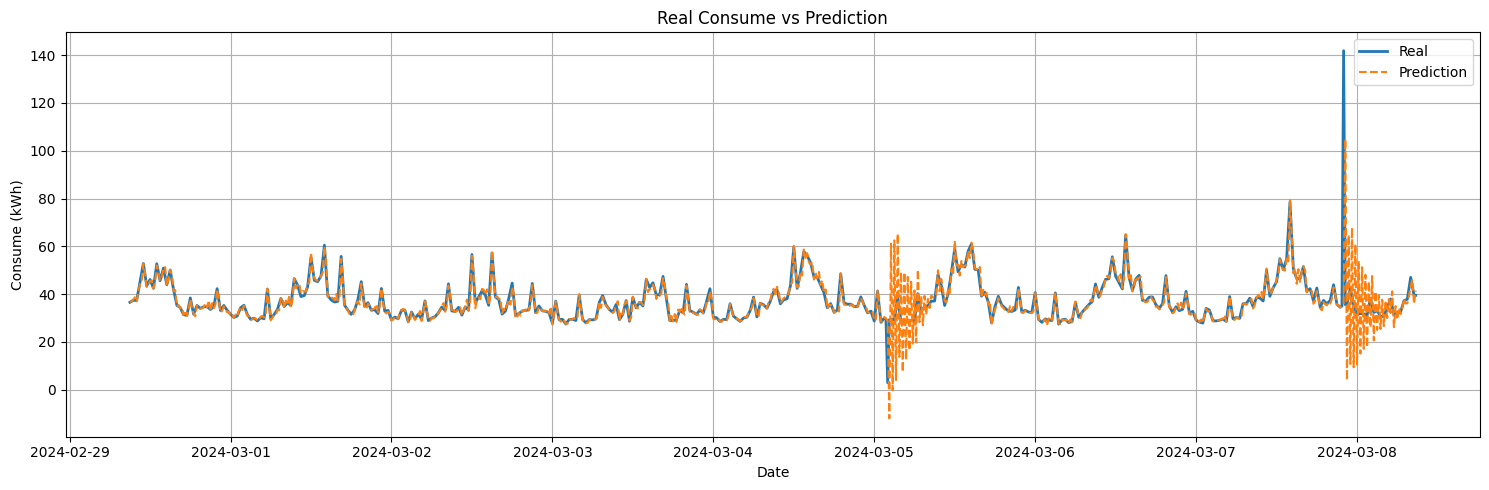

In [49]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=130, n_dias=4, idx=1780):
    PTS_DIA = 96*2
    N = n_dias * PTS_DIA
    end = start + N
    x =50
    plt.figure(figsize=(15, 5))
    #plt.plot(ts.index[x:-97], y_real[x:], label='Real', linewidth=2)
    #plt.plot(ts.index[x:-97], y_pred[x:], label='Prediction', linestyle='--')
    plt.plot(ts.index[start+94+96:end+94+96], y_real[start+94:end+94], label='Real', linewidth=2)
    plt.plot(ts.index[start+94+96:end+94+96], y_pred[start+94:end+94], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=-1, n_dias=4, idx=1780)

107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step


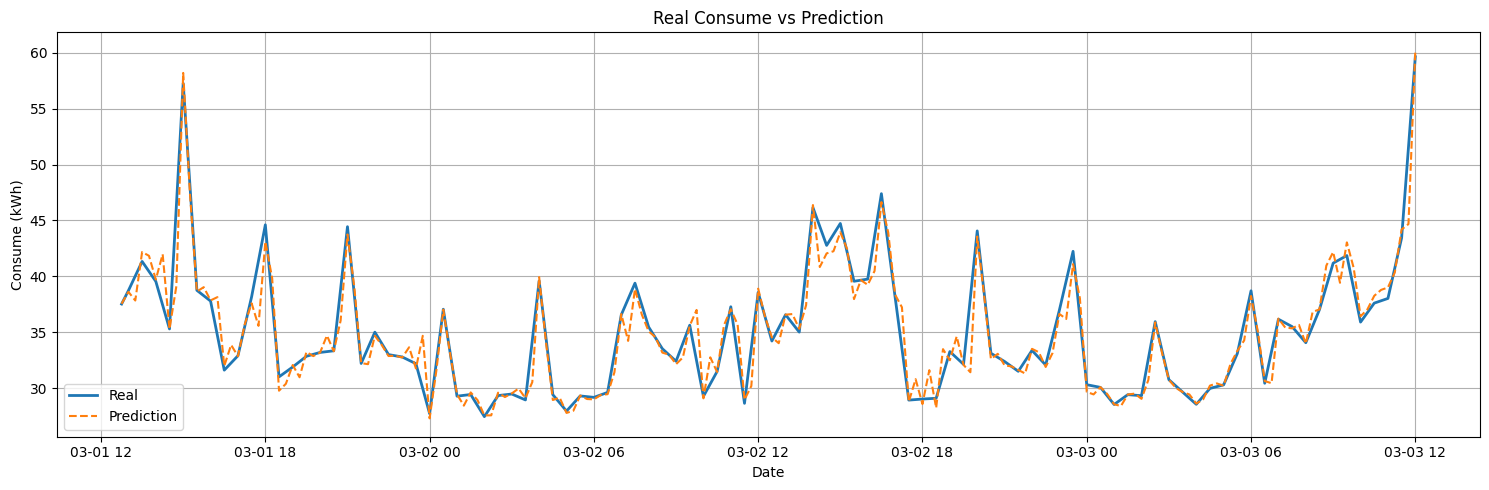

In [50]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=130, n_dias=1, idx=1780):
    PTS_DIA = 96
    N = n_dias * PTS_DIA
    end = start + N

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start+300:end+94+300], y_real[start+300:end+94+300], label='Real', linewidth=2)
    plt.plot(ts.index[start+300:end+94+300], y_pred[start+300:end+94+300], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=0, n_dias=1, idx=1780)

107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
Threshold guardado en threshold_Segai.json


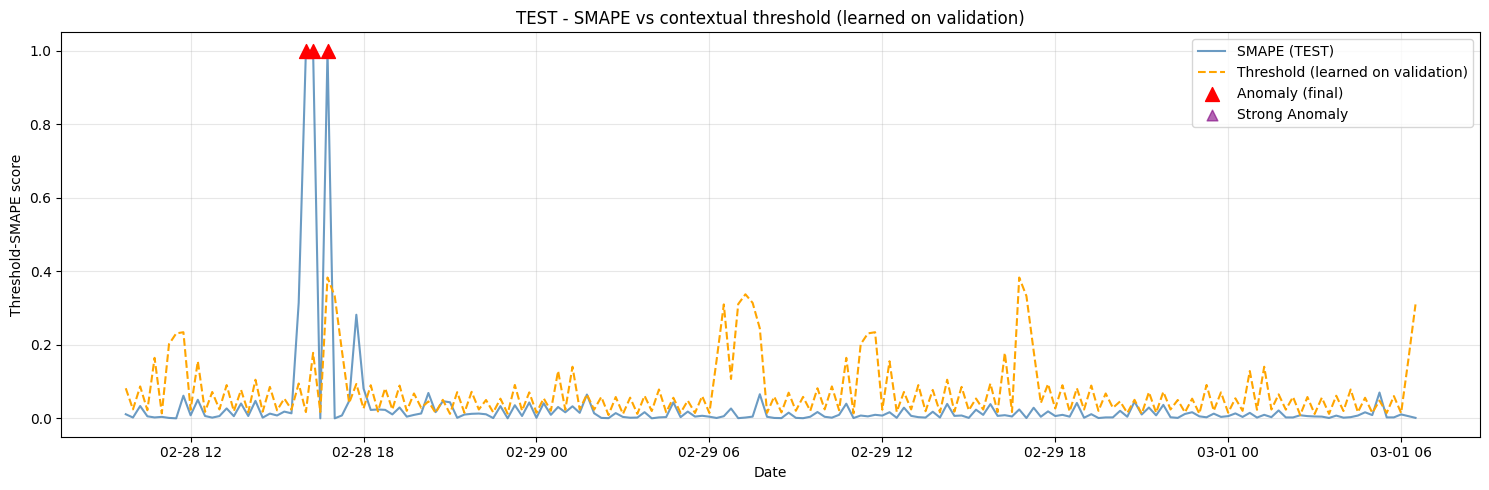

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# PREDICCIONES
# ─────────────────────────────────────────────
y_pred_scaled    = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred_scaled_vl = model_BiLSTM.predict([X_val_temporal, X_val_stat])

y_pred    = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_pred    = np.clip(y_pred, a_min=0, a_max=None)
y_real    = scaler.inverse_transform(y_ts.reshape(-1, 1)).ravel()

y_pred_vl = scaler.inverse_transform(y_pred_scaled_vl.reshape(-1, 1)).ravel()
y_pred_vl = np.clip(y_pred_vl, a_min=0, a_max=None)
y_real_vl = scaler.inverse_transform(y_vl.reshape(-1, 1)).ravel()

# ─────────────────────────────────────────────
# VALIDACIÓN — calcular tau_by_context
# ─────────────────────────────────────────────
df_vl = pd.DataFrame({
    'y_real': y_real_vl,
    'y_pred': y_pred_vl,
}, index=val[96:-1].index)

df_vl['quarter'] = (
    df_vl.index.hour * 4 +
    df_vl.index.minute // 15
)
df_vl['error_kwh'] = np.abs(df_vl['y_real'] - df_vl['y_pred'])
df_vl['score_rel'] = df_vl['error_kwh'] / np.clip(
    df_vl['y_real'] + df_vl['y_pred'], a_min=1e-3, a_max=None
)

P = 0.98  # ✅ Fix 1: proporción directa, sin dividir entre 100

tau_by_context = (
    df_vl
    .groupby('quarter')['score_rel']
    .quantile(P)  # ✅ Fix 1
)
df_vl['tau'] = df_vl['quarter'].map(tau_by_context)

# ─────────────────────────────────────────────
# FUNCIÓN mark_persistent — Fix 4
# ─────────────────────────────────────────────
# def mark_persistent(anomaly_series, min_length=3):
#     result = pd.Series(False, index=anomaly_series.index)
    
#     i = 0
#     while i < len(anomaly_series):
#         if anomaly_series.iloc[i]:  # empieza una racha
#             j = i
#             while j < len(anomaly_series) and anomaly_series.iloc[j]:
#                 j += 1
#             racha_len = j - i
            
#             if racha_len >= min_length:
#                 result.iloc[i:j] = True  # ✅ marca solo los consecutivos
#             # si la racha vuelve a bajar, no marca nada
#             i = j
#         else:
#             i += 1
    
#     return result

# ─────────────────────────────────────────────
# TEST — detección de anomalías
# ─────────────────────────────────────────────
df_test = pd.DataFrame({
    'y_real': y_real,
    'y_pred': y_pred,
}, index=test[96:-1].index)

df_test['quarter'] = (
    df_test.index.hour * 4 +
    df_test.index.minute // 15
)
df_test['error_kwh'] = np.abs(df_test['y_real'] - df_test['y_pred'])
df_test['score_rel'] = df_test['error_kwh'] / np.clip(
    df_test['y_real'] + df_test['y_pred'], a_min=1e-3, a_max=None
)
df_test['tau'] = df_test['quarter'].map(tau_by_context)

# ✅ Fix 2: sin shift(1), la lógica de rachas vive en mark_persistent
df_test['anomaly_strong']     = df_test['score_rel'] > (df_test['tau'] + 0.3)
df_test['anomaly']            = df_test['score_rel'] > (df_test['tau'] + 0.1)
# df_test['anomaly_persistent'] = mark_persistent(df_test['anomaly'], min_length=3)

# ✅ Fix 3: anomaly_final como columna definitiva
df_test['anomaly_final'] = df_test['anomaly_strong'] #| df_test['anomaly_persistent']

import json


threshold_data = {
    "tau_by_context": tau_by_context.to_dict(),  # dict {quarter: tau}
    "horas": df_test.index.astype(str).tolist(),   
    "tau": df_test['tau'].tolist()                
}

with open("threshold_Segai.json", "w") as f:
    json.dump(threshold_data, f, indent=2)

print("Threshold guardado en threshold_Segai.json")


# ─────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────
start = 0
end   = 180

plt.figure(figsize=(15, 5))

plt.plot(
    df_test.index[start:end],
    df_test['score_rel'].iloc[start:end],
    label='SMAPE (TEST)',
    color='steelblue',
    alpha=0.8
)
plt.plot(
    df_test.index[start:end],
    df_test['tau'].iloc[start:end],
    '--',
    label='Threshold (learned on validation)',
    color='orange'
)

# ✅ Fix 3: anomaly_final en rojo como métrica definitiva
anom_final = df_test.iloc[start:end][df_test['anomaly_final'].iloc[start:end]]
plt.scatter(
    anom_final.index,
    anom_final['score_rel'],
    color='red',
    marker='^',
    s=100,
    label='Anomaly (final)',
    zorder=5
)

# anomaly_strong en morado como referencia visual
anom_strong = df_test.iloc[start:end][df_test['anomaly_strong'].iloc[start:end]]
plt.scatter(
    anom_strong.index,
    anom_strong['score_rel'],
    color='purple',
    marker='^',
    s=60,
    label='Strong Anomaly',
    zorder=4,
    alpha=0.6
)

plt.title('TEST - SMAPE vs contextual threshold (learned on validation)')
plt.xlabel('Date')
plt.ylabel('Threshold-SMAPE score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
df_test['is_anomaly'] = df.loc[df_test.index, 'is_anomaly']
df_test['anomaly_type'] = anomaly.loc[df_test.index]
y_true = df_test['is_anomaly'].astype(int)
y_pred = df_test['anomaly_final'].astype(int)

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[3332   75]
 [   0   10]]


In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3407
           1       0.12      1.00      0.21        10

    accuracy                           0.98      3417
   macro avg       0.56      0.99      0.60      3417
weighted avg       1.00      0.98      0.99      3417



In [55]:
from sklearn.metrics import confusion_matrix

for t in ['spike', 'drop']:
    
    y_true_type = (df_test['anomaly_type'] == t).astype(int)
    y_pred = df_test['anomaly_strong'].astype(int)
    
    print(f"\nTipo: {t}")
    print(confusion_matrix(y_true_type, y_pred))


Tipo: spike
[[3332   80]
 [   0    5]]

Tipo: drop
[[3332   80]
 [   0    5]]


In [56]:
model_BiLSTM.save("model_BiLSTM_Segai3.keras")

c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: U

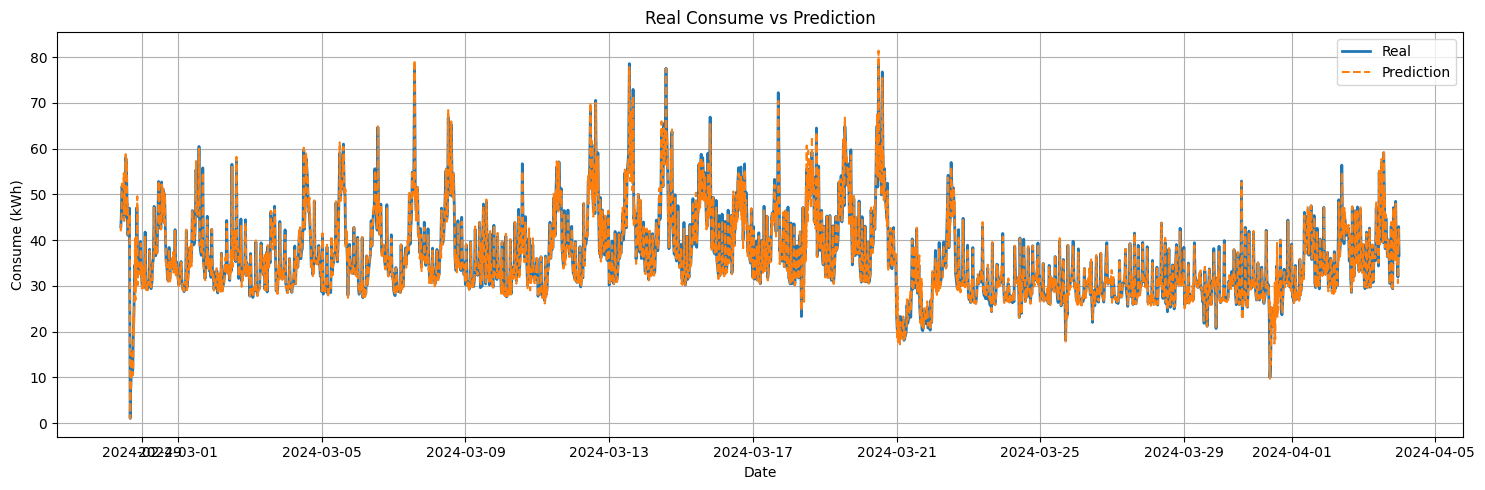

In [57]:
import keyboard

def esperar_tecla(tecla='any'):

    keyboard.wait(tecla)

def scale_data2(train, val, test, scaler):
    tr_scaled = scaler.transform(train.values.reshape(-1, 1)).reshape(train.shape)
    val_scaled = scaler.transform(val.values.reshape(-1, 1)).reshape(val.shape)
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).reshape(test.shape)
    
    return tr_scaled, val_scaled, test_scaled

# ── Antes del bucle ──────────────────────────────────────────
scaler_original = scaler  # tau fue aprendido con este scaler
test_original = test.copy()  # Guarda el test original - NO debe cambiar
test_timestamps = test_original.index.tolist()  # Lista de timestamps para iterar

n_filas_train  = X_train_temporal.shape[0]
n_filas_val    = X_val_temporal.shape[0]
anomaly_streak = 0

list_anomalias = []
list_pred      = []
list_pred_timestamps = []
list_changes   = []
list_reg       = []
list_real      = []
list_anomaly_final = []
list_anomaly_presistent = []
list_anomaly_strong = []

# ── Bucle principal ──────────────────────────────────────────
for idx, timestamp in enumerate(test_timestamps[96:]):
    #esperar_tecla('enter')
    if timestamp not in test.index:
        continue
    current_pos = test.index.get_loc(timestamp)
    temporal_pos = current_pos - 96
    if temporal_pos < 0 or temporal_pos >= X_test_temporal.shape[0]:
        continue
    
    # 1. Prediccion -- siempre con scaler_original
    y_pred_scaled = model_BiLSTM.predict(
        [X_test_temporal[temporal_pos:temporal_pos+1], X_test_stat[temporal_pos:temporal_pos+1]], verbose=0
    )
    y_pred_val = float(scaler_original.inverse_transform(y_pred_scaled)[0][0])
    y_pred_val = max(y_pred_val, 0)
    list_pred.append(y_pred_val)
    list_pred_timestamps.append(timestamp)
    
    y_real_val = float(df.loc[timestamp, 'PLANT CONSUMPTION (KWh)'])
    #print(f"Timestamp: {timestamp} | Predicted: {y_pred_val:.3f} kWh | Real: {y_real_val:.3f} kWh")
    list_real.append(y_real_val)

    # 2. Score relativo
    quarter   = timestamp.hour * 4 + timestamp.minute // 15
    tau       = tau_by_context[quarter]
    score_rel = abs(y_real_val - y_pred_val) / max(y_real_val + y_pred_val, 1e-3)

    # 3. Deteccion
    anomaly_strong     = score_rel > (tau + 0.3)
    list_anomaly_strong.append(anomaly_strong)
    anomaly            = score_rel > (tau + 0.1)
    anomaly_streak     = anomaly_streak + 1 if anomaly else 0
    anomaly_persistent = anomaly_streak >= 3
    list_anomaly_presistent.append(anomaly_persistent)
    anomaly_final      = anomaly_strong or anomaly_persistent
    list_anomaly_final.append(anomaly_final)
    
    # 4. Correccion si hay anomalia
    if anomaly_final:
        valor_original = df.loc[timestamp, 'PLANT CONSUMPTION (KWh)']

        list_anomalias.append(timestamp)
        list_changes.append((valor_original, y_pred_val, y_real_val, score_rel, ))
        list_reg.append({
            'fecha'          : timestamp,
            'valor_original' : valor_original,
            'nuevo_valor'    : y_pred_val,
        })

        df.loc[timestamp, 'PLANT CONSUMPTION (KWh)'] = y_pred_val

        df_stat = stadistical_features(df)
        train, val, test = divide_data(df_stat, train_size=0.8, val_size=0.1)

        cyclic_cols  = ["hora_sin", "hora_cos", "dia_semana", "is_on", "is_anomaly"]
        train_cyclic = train[cyclic_cols].values
        val_cyclic   = val[cyclic_cols].values
        test_cyclic  = test[cyclic_cols].values

        tr_scaled, val_scaled, test_scaled = scale_data2(
            train.drop(columns=cyclic_cols),
            val.drop(columns=cyclic_cols),
            test.drop(columns=cyclic_cols),
            scaler_original
        )

        X_train_scaled = np.concatenate([tr_scaled, train_cyclic], axis=1)
        X_val_scaled   = np.concatenate([val_scaled, val_cyclic], axis=1)
        X_test_scaled  = np.concatenate([test_scaled, test_cyclic], axis=1)

        X_train_temporal, y_tr = window(X_train_scaled, input_length=96, output_length=1)
        X_val_temporal,   y_vl = window(X_val_scaled,   input_length=96, output_length=1)
        X_test_temporal,  y_ts = window(X_test_scaled,  input_length=96, output_length=1)

        X_train_stat = X_train_scaled[95:-2, 1:-1]
        X_val_stat   = X_val_scaled[95:-2, 1:-1]
        X_test_stat  = X_test_scaled[95:-2, 1:-1]

        n_filas_train = X_train_temporal.shape[0]
        n_filas_val   = X_val_temporal.shape[0]
        # ✅ scaler_original NO se actualiza nunca

# ── Plot ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

y_pred_all = np.array(list_pred)
pred_index = pd.Index(list_pred_timestamps)
y_test_real_all = df.loc[pred_index, 'PLANT CONSUMPTION (KWh)'].values

plt.figure(figsize=(15, 5))
plt.plot(pred_index, y_test_real_all, label='Real', linewidth=2)
plt.plot(pred_index, y_pred_all, label='Prediction', linestyle='--')
plt.title('Real Consume vs Prediction')
plt.xlabel('Date')
plt.ylabel('Consume (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show(block=True)

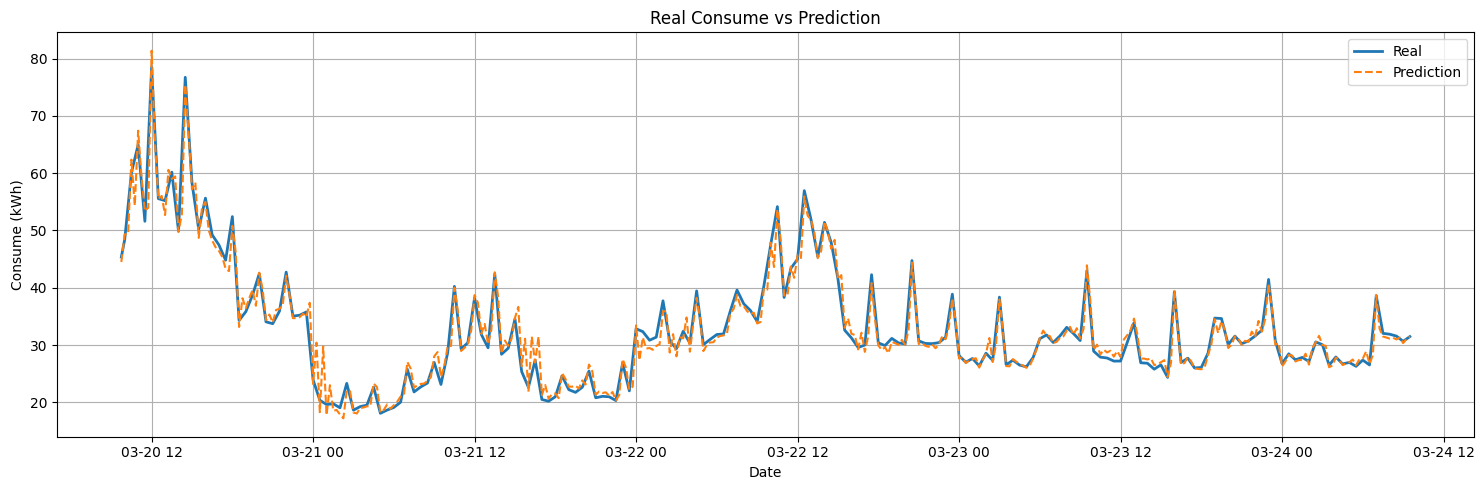

In [58]:
def plot_window(ts, y_real, y_pred, start=0, n_dias=4):
    PTS_DIA = 96  # ✅ 96 puntos/día si datos son cada 15 min
    N = n_dias * PTS_DIA
    end = start + N
    offset_ts = 96  # ventana temporal desplaza el índice de ts

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start + offset_ts : end + offset_ts], 
             y_real[start:end], 
             label='Real', linewidth=2)
    plt.plot(ts.index[start + offset_ts : end + offset_ts], 
             y_pred[start:end], 
             label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)



y_pred_all      = np.array(list_pred)
y_test_real_all = scaler_original.inverse_transform(y_ts.reshape(-1, 1)).flatten()  # ✅ scaler_original
x = 19
plot_window(
    test,
    y_test_real_all,
    y_pred_all,
    start=192 +96 * x ,
    n_dias=4,
)


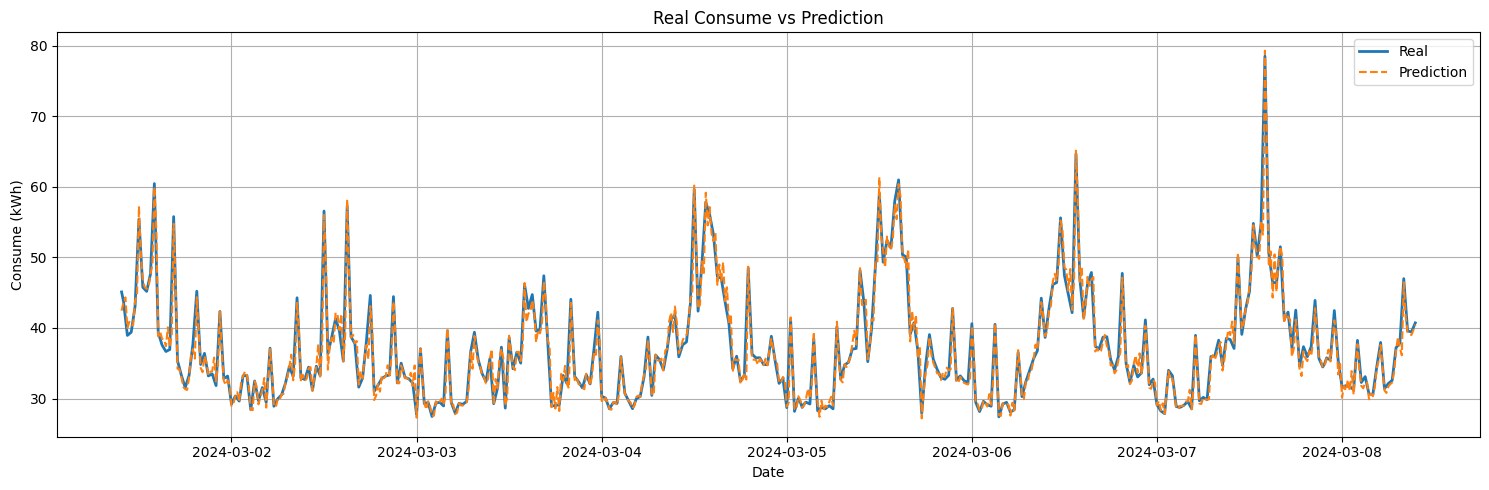

In [59]:
# ✅ list_pred ya contiene floats desescalados
y_pred_all = np.array(list_pred)  # shape: (n_samples,)
y_test_real_all = scaler.inverse_transform(y_ts.reshape(-1, 1)).flatten()

plot_window(
    test,
    y_test_real_all, 
    y_pred_all,
    start=192,
    n_dias=7,
)


In [60]:
eval_reg(y_test_real_all, y_pred_all, 'TEST')

TEST:
  MSE:   3.954
  RMSE:  1.989
  MAE:   1.180
  MAPE:  3.20%
  SMAPE: 3.21%
  R²:    0.9487



In [61]:
eval_reg(y_test_real_all[1:], y_test_real_all[:-1], 'TEST')

TEST:
  MSE:   13.178
  RMSE:  3.630
  MAE:   2.593
  MAPE:  7.51%
  SMAPE: 6.91%
  R²:    0.8290



In [62]:
List_is_anomaly = df.loc[pred_index, 'is_anomaly'].values
cm = confusion_matrix(List_is_anomaly, list_anomaly_final)
print(cm)

[[3387   20]
 [   0   10]]


In [63]:
print(classification_report(List_is_anomaly, list_anomaly_final))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3407
           1       0.33      1.00      0.50        10

    accuracy                           0.99      3417
   macro avg       0.67      1.00      0.75      3417
weighted avg       1.00      0.99      1.00      3417



In [64]:
from sklearn.metrics import confusion_matrix

for t in ['spike', 'drop']:
    
    y_true_type = (df_test['anomaly_type'] == t).astype(int)
    y_pred = list_anomaly_strong
    
    print(f"\nTipo: {t}")
    print(confusion_matrix(y_true_type, y_pred))


Tipo: spike
[[3391   21]
 [   0    5]]

Tipo: drop
[[3391   21]
 [   0    5]]
